# SaaS Customer Churn Analysis

## Project Overview

This project analyzes customer churn behavior for a SaaS company.  
The goal is to identify factors associated with customer cancellations and predict which customers are most likely to churn.

The analysis includes:

- Exploratory Data Analysis
- Customer risk segmentation
- Machine learning churn prediction
- Revenue at risk estimation

Tools used:
Python, Pandas, Scikit-learn, Jupyter Notebook

## Generate Synthetic SaaS Customer Dataset

In this step we simulate a dataset representing customers of a SaaS company.  
The dataset includes variables such as subscription price, customer tenure, product usage, and support activity.

A churn variable is also generated to represent whether a customer cancelled the service.

In [10]:
import pandas as pd
import numpy as np

np.random.seed(42)

n_customers = 10000

data = pd.DataFrame({
    "customer_id": range(1, n_customers + 1),
    "monthly_fee": np.random.choice([10,20,30,50,100], n_customers),
    "tenure_months": np.random.randint(1,48,n_customers),
    "support_tickets": np.random.poisson(1.5,n_customers),
    "logins_per_month": np.random.randint(1,60,n_customers)
})

data["churn"] = np.where(
    (data["support_tickets"] > 3) & (data["logins_per_month"] < 10),
    1,
    np.random.choice([0,1], n_customers, p=[0.85,0.15])
)

data.head()

,customer_id,monthly_fee,tenure_months,support_tickets,logins_per_month,churn
0,1,50,7,0,55,0
1,2,100,36,0,51,1
2,3,30,29,3,30,0
3,4,100,24,1,52,0
4,5,100,39,4,46,0


In [21]:
data.to_csv("saas_customers.csv", index=False)

## Check Available Files in the Working Directory

This step verifies which files exist in the current project folder to confirm that the dataset file is available for analysis.

In [22]:
import os
os.listdir()

['.ipynb_checkpoints',
 '.jupyter',
 '.virtual_documents',
 'docs',
 'saas_customers.csv',
 'saas_customer_analysis-Copy1.ipynb',
 'saas_customer_analysis.ipynb']

## Load the SaaS Customer Dataset

The dataset containing customer information is loaded into a pandas DataFrame for analysis.

In [23]:
df = pd.read_csv("saas_customers.csv")
df.head()

,customer_id,monthly_fee,tenure_months,support_tickets,logins_per_month,churn
0,1,50,7,0,55,0
1,2,100,36,0,51,1
2,3,30,29,3,30,0
3,4,100,24,1,52,0
4,5,100,39,4,46,0


## Calculate Monthly Recurring Revenue (MRR)

Monthly Recurring Revenue represents the total monthly subscription revenue generated by all active customers.

In [24]:
mrr = df["monthly_fee"].sum()
mrr

np.int64(419730)

## Calculate Overall Customer Churn Rate

This calculation determines the percentage of customers who cancelled the service.

In [25]:
churn_rate = df["churn"].mean()
churn_rate

np.float64(0.1569)

## Analyze Churn by Number of Support Tickets

This analysis explores whether customers who contact support more frequently are more likely to churn.

In [26]:
df.groupby("support_tickets")["churn"].mean()

support_tickets
0    0.148131
1    0.151268
2    0.152794
3    0.146322
4    0.256018
5    0.290323
6    0.171429
7    0.142857
8    0.000000
9    0.000000
Name: churn, dtype: float64

## Inspect Dataset Columns

This step checks the structure of the dataset and confirms the available variables for analysis.

In [27]:
df.columns

Index(['customer_id', 'monthly_fee', 'tenure_months', 'support_tickets',
       'logins_per_month', 'churn'],
      dtype='object')

## Analyze Churn by Platform Usage

This analysis evaluates whether customers who use the platform less frequently are more likely to cancel the service.

In [28]:
df.groupby("logins_per_month")["churn"].mean()

logins_per_month
1     0.193939
2     0.222798
3     0.255319
4     0.161677
5     0.137566
6     0.149425
7     0.170588
8     0.146853
9     0.265193
10    0.162011
11    0.154286
12    0.132450
13    0.160494
14    0.182390
15    0.165680
16    0.137931
17    0.104895
18    0.140244
19    0.125654
20    0.208861
21    0.160221
22    0.170000
23    0.109290
24    0.089744
25    0.157895
26    0.088050
27    0.110429
28    0.152174
29    0.096970
30    0.152439
31    0.217687
32    0.141176
33    0.152047
34    0.152866
35    0.144654
36    0.106918
37    0.190184
38    0.163743
39    0.191257
40    0.137056
41    0.190789
42    0.196203
43    0.149701
44    0.182390
45    0.190722
46    0.135484
47    0.166667
48    0.131250
49    0.142857
50    0.126582
51    0.132530
52    0.166667
53    0.146199
54    0.169312
55    0.179191
56    0.138889
57    0.156069
58    0.148352
59    0.109756
Name: churn, dtype: float64

## Support Tickets Distribution and Churn Rate

This step examines how many customers fall into each support ticket category and the corresponding churn rate.

In [29]:
df.groupby("support_tickets")["churn"].agg(["count","mean"])

,count,mean
support_tickets,,
0,2194,0.148131
1,3312,0.151268
2,2631,0.152794
3,1237,0.146322
4,457,0.256018
5,124,0.290323
6,35,0.171429
7,7,0.142857
8,2,0.000000


## Analyze Churn by Customer Tenure

Customer tenure represents how long a customer has been subscribed to the service.  
This analysis investigates whether longer-term customers are less likely to churn.

In [30]:
df.groupby("tenure_months")["churn"].mean()

tenure_months
1     0.143519
2     0.152381
3     0.193396
4     0.152381
5     0.197183
6     0.142857
7     0.129464
8     0.158590
9     0.193548
10    0.175439
11    0.161677
12    0.148718
13    0.139831
14    0.120690
15    0.166667
16    0.176471
17    0.120833
18    0.175115
19    0.141593
20    0.150000
21    0.160870
22    0.179245
23    0.209402
24    0.158371
25    0.166667
26    0.115556
27    0.146919
28    0.190476
29    0.176190
30    0.158163
31    0.169725
32    0.147059
33    0.201058
34    0.155660
35    0.131868
36    0.179245
37    0.141414
38    0.136792
39    0.154589
40    0.162896
41    0.174129
42    0.144928
43    0.141361
44    0.129310
45    0.164384
46    0.113861
47    0.129032
Name: churn, dtype: float64

In [31]:
df["churn"].mean()

np.float64(0.1569)

## Convert Churn Rate to Percentage

This converts the churn rate into percentage format for easier interpretation.

In [32]:
df["churn"].mean()*100

np.float64(15.690000000000001)

## Visualizing Churn by Support Tickets

A bar chart is created to illustrate how churn rate changes based on the number of support tickets submitted.

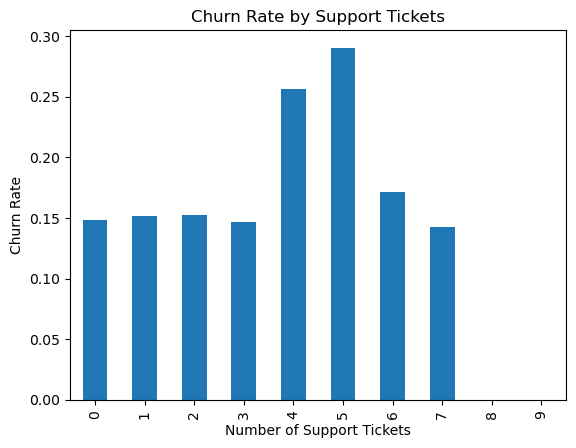

In [33]:
import matplotlib.pyplot as plt

df.groupby("support_tickets")["churn"].mean().plot(kind="bar")

plt.title("Churn Rate by Support Tickets")
plt.ylabel("Churn Rate")
plt.xlabel("Number of Support Tickets")

plt.show()

## Visualizing Churn by Support Tickets

A bar chart is created to illustrate how churn rate changes based on the number of support tickets submitted.

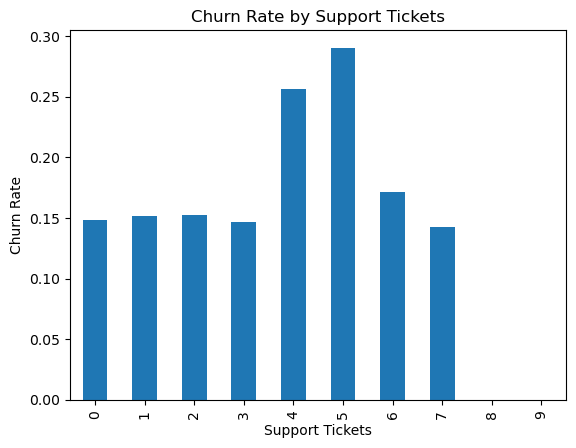

In [34]:
import matplotlib.pyplot as plt

churn_by_tickets = df.groupby("support_tickets")["churn"].mean()

plt.figure()
churn_by_tickets.plot(kind="bar")
plt.xlabel("Support Tickets")
plt.ylabel("Churn Rate")
plt.title("Churn Rate by Support Tickets")
plt.show()

## Improved Visualization of Churn by Support Tickets

This step creates a clearer visualization showing how churn rate varies with customer support activity.

In [35]:
high_risk = df[df["support_tickets"] >= 4]

len(high_risk)

626

In [36]:
high_risk["churn"].mean()

np.float64(0.25559105431309903)

## Churn Rate Among High-Risk Customers

This calculates the churn rate specifically for customers with high support ticket activity.

In [37]:
high_risk["churn"].mean()*100

np.float64(25.559105431309902)

In [38]:
df["churn"].mean()

np.float64(0.1569)

## Compare with Overall Churn Rate

This provides a baseline churn rate across the entire customer base.

In [39]:
df["churn"].mean()*100

np.float64(15.690000000000001)

## Churn Rate by Platform Usage

This analysis examines how customer engagement with the platform affects churn behavior.  
Specifically, it calculates the churn rate for different levels of monthly logins.

Lower platform usage may indicate lower engagement and potentially higher churn risk.

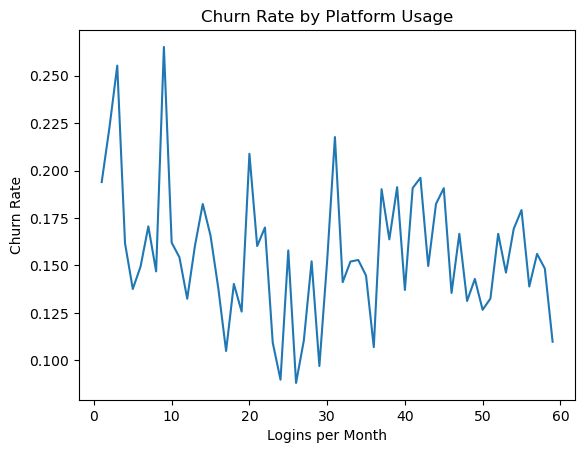

In [40]:
import matplotlib.pyplot as plt

churn_by_logins = df.groupby("logins_per_month")["churn"].mean()

plt.figure()
churn_by_logins.plot(kind="line")
plt.xlabel("Logins per Month")
plt.ylabel("Churn Rate")
plt.title("Churn Rate by Platform Usage")
plt.show()

## Churn Rate by Customer Tenure

Customer tenure represents how long a customer has been subscribed to the service.

This analysis calculates the churn rate for each tenure level to determine whether longer-term customers are less likely to cancel their subscription.

In [41]:
df.groupby("tenure_months")["churn"].mean()

tenure_months
1     0.143519
2     0.152381
3     0.193396
4     0.152381
5     0.197183
6     0.142857
7     0.129464
8     0.158590
9     0.193548
10    0.175439
11    0.161677
12    0.148718
13    0.139831
14    0.120690
15    0.166667
16    0.176471
17    0.120833
18    0.175115
19    0.141593
20    0.150000
21    0.160870
22    0.179245
23    0.209402
24    0.158371
25    0.166667
26    0.115556
27    0.146919
28    0.190476
29    0.176190
30    0.158163
31    0.169725
32    0.147059
33    0.201058
34    0.155660
35    0.131868
36    0.179245
37    0.141414
38    0.136792
39    0.154589
40    0.162896
41    0.174129
42    0.144928
43    0.141361
44    0.129310
45    0.164384
46    0.113861
47    0.129032
Name: churn, dtype: float64

## Visualization of Churn by Customer Tenure

This visualization shows how churn rate changes depending on how long customers have been using the service.

It helps identify whether newer customers are more likely to churn compared to long-term customers.

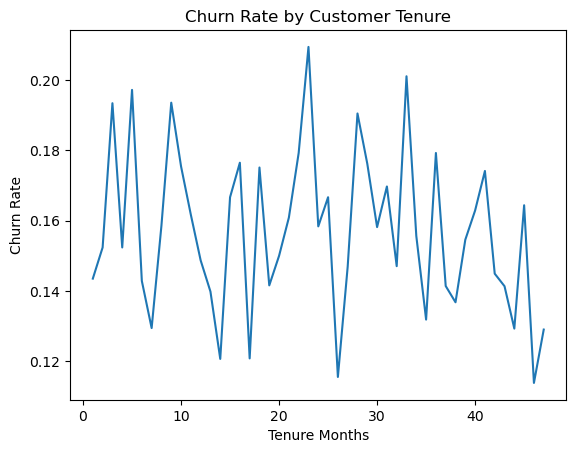

In [42]:
churn_by_tenure = df.groupby("tenure_months")["churn"].mean()

plt.figure()
churn_by_tenure.plot(kind="line")
plt.xlabel("Tenure Months")
plt.ylabel("Churn Rate")
plt.title("Churn Rate by Customer Tenure")
plt.show()

In [43]:
def risk_segment(row):

    if row["support_tickets"] >= 4:
        return "High Risk"

    elif row["logins_per_month"] < 5:
        return "Medium Risk"

    else:
        return "Low Risk"

df["risk_segment"] = df.apply(risk_segment, axis=1)

## Customer Risk Segment Distribution

Customers are categorized into risk segments based on behavioral characteristics such as engagement and support activity.

This step counts how many customers fall into each risk category.

In [44]:
df["risk_segment"].value_counts()

risk_segment
Low Risk       8701
Medium Risk     673
High Risk       626
Name: count, dtype: int64

## Churn Rate by Risk Segment

This analysis evaluates whether the defined risk segments accurately reflect real churn behavior by measuring the churn rate within each segment.

In [45]:
df.groupby("risk_segment")["churn"].mean()

risk_segment
High Risk      0.255591
Low Risk       0.149293
Medium Risk    0.163447
Name: churn, dtype: float64

In [46]:
X = df[["monthly_fee","tenure_months","support_tickets","logins_per_month"]]
y = df["churn"]

In [47]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [48]:
!pip install scikit-learn

In [49]:
import sklearn
print("sklearn instalado")

sklearn instalado


In [50]:
from sklearn.model_selection import train_test_split

In [51]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [52]:
df.columns

Index(['customer_id', 'monthly_fee', 'tenure_months', 'support_tickets',
       'logins_per_month', 'churn', 'risk_segment'],
      dtype='object')

In [53]:
X = df[["tenure_months", "monthly_fee", "support_tickets", "logins_per_month"]]
y = df["churn"]

In [54]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [55]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [56]:
model.score(X_test, y_test)

0.81

## Machine Learning Model Accuracy

This step evaluates the performance of the churn prediction model by measuring its accuracy on the test dataset.

In [57]:
model.score(X_test, y_test)*100

81.0

## Feature Importance Analysis

This analysis identifies which variables contribute the most to predicting customer churn.

Understanding feature importance helps explain which customer behaviors have the strongest impact on churn risk.

In [58]:
import pandas as pd

feature_importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importance

logins_per_month    0.422766
tenure_months       0.355489
support_tickets     0.115733
monthly_fee         0.106012
dtype: float64

## Preview High-Risk Customers Identified by the Model

This step displays customers with the highest predicted probability of churn.

## Predicting Churn Probability for Each Customer

Using the trained machine learning model, we estimate the probability that each customer will churn.

This probability allows the company to identify customers who are most at risk of cancelling their subscription.

In [59]:
df["churn_probability"] = model.predict_proba(X)[:,1]

df.head()

,customer_id,monthly_fee,tenure_months,support_tickets,logins_per_month,churn,risk_segment,churn_probability
0,1,50,7,0,55,0,Low Risk,0.05
1,2,100,36,0,51,1,Low Risk,0.83
2,3,30,29,3,30,0,Low Risk,0.06
3,4,100,24,1,52,0,Low Risk,0.20
4,5,100,39,4,46,0,High Risk,0.14


## Identifying High-Risk Customers

Customers with a predicted churn probability greater than 70% are classified as high-risk customers.

These customers are the most likely to cancel their subscription and may require proactive retention strategies.

In [60]:
high_risk_customers = df[df["churn_probability"] > 0.7]

## Preview High-Risk Customers Identified by the Model

This step displays customers with the highest predicted probability of churn.

## Preview High-Risk Customers

This step displays the first few customers identified as having a high probability of churn.

In [61]:
high_risk_customers.head()

,customer_id,monthly_fee,tenure_months,support_tickets,logins_per_month,churn,risk_segment,churn_probability
1,2,100,36,0,51,1,Low Risk,0.830000
22,23,50,9,1,55,1,Low Risk,0.750000
41,42,10,31,0,19,1,Low Risk,0.760000
47,48,100,11,1,33,1,Low Risk,0.797751
48,49,20,2,0,32,1,Low Risk,0.770000


## Revenue Associated with High-Risk Customers

This calculates the total monthly revenue generated by customers likely to churn.

## Total Number of High-Risk Customers

This calculates how many customers are classified as high churn risk according to the machine learning model.

In [62]:
len(high_risk_customers)

504

## Revenue Associated with High-Risk Customers

This calculates the total monthly revenue generated by customers likely to churn.

In [63]:
high_risk_customers["monthly_fee"].sum()

np.int64(21500)

In [64]:
def ai_risk_segment(prob):

    if prob > 0.7:
        return "High Risk"
    elif prob > 0.4:
        return "Medium Risk"
    else:
        return "Low Risk"

df["ai_risk_segment"] = df["churn_probability"].apply(ai_risk_segment)

## AI-Based Risk Segmentation Distribution

Customers are categorized into Low, Medium, and High risk segments based on predicted churn probability.

In [65]:
df["ai_risk_segment"].value_counts()

ai_risk_segment
Low Risk       8479
Medium Risk    1017
High Risk       504
Name: count, dtype: int64

## Model Validation by Risk Segment

This verifies whether the predicted risk segments correspond with actual churn outcomes.

In [66]:
df.groupby("ai_risk_segment")["churn"].mean()

ai_risk_segment
High Risk      0.974206
Low Risk       0.035146
Medium Risk    0.766962
Name: churn, dtype: float64

## Top 10 Customers with Highest Churn Probability

This step identifies the customers most likely to cancel their subscription.

In [69]:
df.sort_values("churn_probability", ascending=False).head(10)

,customer_id,monthly_fee,tenure_months,support_tickets,logins_per_month,churn,risk_segment,churn_probability,ai_risk_segment
9999,10000,30,14,4,3,1,High Risk,1.0,High Risk
9848,9849,50,26,4,2,1,High Risk,1.0,High Risk
2450,2451,50,21,5,3,1,High Risk,1.0,High Risk
8754,8755,50,23,4,2,1,High Risk,1.0,High Risk
7448,7449,10,15,5,3,1,High Risk,1.0,High Risk
7493,7494,50,29,4,3,1,High Risk,1.0,High Risk
8721,8722,20,16,4,6,1,High Risk,1.0,High Risk
7510,7511,30,29,4,1,1,High Risk,1.0,High Risk
7818,7819,50,35,5,7,1,High Risk,1.0,High Risk
7864,7865,30,20,4,5,1,High Risk,1.0,High Risk


In [70]:
df.head()

,customer_id,monthly_fee,tenure_months,support_tickets,logins_per_month,churn,risk_segment,churn_probability,ai_risk_segment
0,1,50,7,0,55,0,Low Risk,0.05,Low Risk
1,2,100,36,0,51,1,Low Risk,0.83,High Risk
2,3,30,29,3,30,0,Low Risk,0.06,Low Risk
3,4,100,24,1,52,0,Low Risk,0.20,Low Risk
4,5,100,39,4,46,0,High Risk,0.14,Low Risk


In [71]:
df.columns

Index(['customer_id', 'monthly_fee', 'tenure_months', 'support_tickets',
       'logins_per_month', 'churn', 'risk_segment', 'churn_probability',
       'ai_risk_segment'],
      dtype='object')

In [72]:
df["churn"].mean()

np.float64(0.1569)

## Final Churn Rate Verification

This confirms the final churn rate observed in the dataset.

In [73]:
df["churn"].mean()*100

np.float64(15.690000000000001)

## Total Monthly Revenue Calculation

This confirms the total monthly recurring revenue generated by the company.

In [74]:
df["monthly_fee"].sum()

np.int64(419730)

## Calculate Revenue at Risk

This calculates how much revenue could be lost if high-risk customers churn.

In [75]:
revenue_at_risk = high_risk_customers["monthly_fee"].sum()

revenue_at_risk

np.int64(21500)

In [76]:
revenue_at_risk / df["monthly_fee"].sum()

np.float64(0.05122340552259786)

## Statistical Summary of High-Risk Customers

This provides descriptive statistics for customers identified as high churn risk.

In [77]:
revenue_at_risk / df["monthly_fee"].sum()*100

np.float64(5.122340552259786)

## Statistical Summary of High-Risk Customers

This provides descriptive statistics for customers identified as high churn risk.

In [78]:
high_risk_customers.describe()

,customer_id,monthly_fee,tenure_months,support_tickets,logins_per_month,churn,churn_probability
count,504.000000,504.000000,504.000000,504.000000,504.000000,504.000000,504.000000
mean,4907.509921,42.658730,22.845238,1.896825,25.865079,0.974206,0.806407
std,2805.497247,32.005134,13.258399,1.528155,18.161460,0.158677,0.095273
min,2.000000,10.000000,1.000000,0.000000,1.000000,0.000000,0.700833
25%,2500.750000,20.000000,12.000000,1.000000,9.000000,1.000000,0.731000
50%,4851.500000,30.000000,23.000000,2.000000,22.000000,1.000000,0.770000
75%,7213.500000,50.000000,34.000000,3.000000,42.000000,1.000000,0.860000
max,10000.000000,100.000000,47.000000,7.000000,59.000000,1.000000,1.000000


## Key Findings

The analysis revealed several important insights:

1. The overall churn rate is 15.69%.
2. Customers with low product engagement are significantly more likely to churn.
3. High support ticket volume is associated with increased churn risk.
4. The machine learning model identifies 504 customers as high churn risk.
5. These customers represent $21,500 in monthly revenue at risk.
6. This equals approximately 5.1% of total company revenue.

## Business Recommendations

To reduce churn, the company should:

- Improve onboarding for new customers
- Increase product engagement
- Proactively support customers with frequent issues

In [79]:
import pandas as pd

In [81]:
import numpy as np

In [82]:
import matplotlib.pyplot as plt

In [83]:
df = pd.read_csv("saas_customers.csv")
df.head()

,customer_id,monthly_fee,tenure_months,support_tickets,logins_per_month,churn
0,1,50,7,0,55,0
1,2,100,36,0,51,1
2,3,30,29,3,30,0
3,4,100,24,1,52,0
4,5,100,39,4,46,0


In [84]:
X = df[["tenure_months","monthly_fee","support_tickets","logins_per_month"]]
y = df["churn"]

In [85]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [86]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [87]:
df["churn"].mean()*100

np.float64(15.690000000000001)

In [88]:
high_risk_customers["monthly_fee"].sum()

np.int64(21500)

In [89]:
revenue_at_risk / df["monthly_fee"].sum()*100

np.float64(5.122340552259786)